In [94]:
import sys
sys.path.append(r"C:\nirfasterFF")
import nirfasterff as ff # ff is short for fast and furious
import numpy as np
import matplotlib.pyplot as plt

In [95]:
mua = 0.01
mus = 0.33 # approx same as musp here
ri = 1.33
mua_pert_percent = 0.01
mus_pert_percent = 0.01

In [106]:
vol = 2 * np.ones((60,60,60))
vol = vol.astype(np.uint8)

meshing_params = ff.utils.MeshingParams(
    xPixelSpacing=0.5,  
    yPixelSpacing=0.5,
    SliceThickness=0.5,
    general_cell_size=1.0,  
    cell_radius_edge=1.5,  
    facet_size=1.5, 
    facet_distance=1.0
)
# call the mesher
ele, nodes = ff.meshing.RunCGALMeshGenerator(vol, opt = meshing_params)

In [107]:
mesh = ff.base.stndmesh()
mesh.from_solid(ele, nodes)

# for each row, [region, mua(mm-1), musp(mm-1), ri]
prop = np.array([[1, mua, mus, ri]])
mesh.set_prop(prop)
mesh.kappa = 1 / (3*(mesh.mua + mesh.mus))
# set link (source-detector pairs)
mesh.link = np.array([[1,1,1]],dtype=np.int32)
# optodes
mesh.source = ff.base.optode(np.array([5,30,60]))
mesh.meas = ff.base.optode(np.array([55,30,60]))
# move them (for non-fixed) and calculate the integration function
mesh.touch_optodes()

touching sources
touching detectors


Create grid space

In [108]:
cube_grid_dim = 60  #side=60mm

xgrid = np.arange(0., cube_grid_dim, 0.5)
ygrid = np.arange(0., cube_grid_dim, 0.5)
zgrid = np.arange(0., cube_grid_dim, 0.5)

mesh.gen_intmat(xgrid, ygrid, zgrid)

#### TEST 1: comparing [mua-Perturbation method-doD    vs     mua-jacobian method-doD] for DC mesh

In [109]:
#Scan parameters
start = 10
stop = 50
step = 10

posList = range(start,stop+1,step)
nPos = len(posList)

In [110]:
J_DC_mua = mesh.jacobian(normalize=False)[0]     # mua-Jacobian of main mesh

data_DC = mesh.femdata(0)[0]                     #  measured DC boundary data
data_DC = data_DC.amplitude



doD_mua_pert = np.zeros(nPos)
doD_mua_jacobian = np.zeros(nPos)
error_mua = np.zeros(nPos)

print('\n')

for i in range(0,nPos):
   mesh_pert = ff.base.stndmesh()  # creating duplicate of mesh for measuring mua-perturbed-perturbation-model doD
   mesh_pert.from_copy(mesh)       
   


   # add a spherical absorption inclusion in mesh_pert
   dia_ab =  2   #diameter of spherical absorber
   x_cen_ab,y_cen_ab,z_cen_ab = [30,30,posList[i]]      #centre of the absorber
   dist_ab = np.sqrt(np.square((mesh.nodes[:,0]-x_cen_ab)) + np.square((mesh.nodes[:,1]-y_cen_ab)) + np.square((mesh.nodes[:,2]-z_cen_ab)))
   ind_ab = dist_ab < dia_ab/2
   mua_selection = np.where(ind_ab)           #of all node points, this is the selection of nodes where the absorber inclusion exists



   # Modify the mua-map of mesh_pert(in mesh-space) by some percentage, and calculate the forward data and sebsequently the perturbation doD
   mesh_pert.mua[mua_selection] = mesh_pert.mua[mua_selection] + mua_pert_percent*mesh_pert.mua[mua_selection] 
   mesh_pert.kappa[mua_selection] = 1.0 / (3.0*(mesh_pert.mua[mua_selection] + mesh_pert.mus[mua_selection]))
   
   data_mesh_pert = mesh_pert.femdata(0)[0] 
   data_mesh_pert = data_mesh_pert.amplitude


   doD_mua_pert[i] = (data_mesh_pert - data_DC).item()
  

   # Now calculate doD using the Jacobian method
   # creating the difference in absorption for selected nodes(to be multiplied with mua-Jacobian) in mesh-space and then interpolated to grid-space 
   tmp1= np.zeros(len(mesh.nodes))    #all meshes are derived from the original main 'mesh', hence its alright to use 'mesh.nodes'
   tmp1[mua_selection] = mua_pert_percent*mesh.mua[mua_selection]         # this is the effective difference in abs (in mesh-space). a 1% change in 'just absorption' 
   dmua = mesh.vol.mesh2grid@tmp1     # mesh to grid interpolation (difference in abs in grid-space) - (1728000,1)
   doD_mua_jacobian[i] = (J_DC_mua @ dmua).item()
   
   
   error_mua[i] = (((doD_mua_jacobian[i]-doD_mua_pert[i])/doD_mua_pert[i])*100)


   #Compare
   print(f"doD from US-perturbed-absorption-blob-perturbation model at z = {cube_grid_dim-((i+1)*step)} mm:", doD_mua_pert[i])      # {60-((i+1)*step)} , the (i+1) is because  while displaying, we dont want 'i' to start from 1.
   print(f"doD from US-perturbed-absorption-blob-Jacobian: model at z = {cube_grid_dim-((i+1)*step)} mm:", doD_mua_jacobian[i])
   print('percentage error:' , error_mua[i])
   print('\n')

Calculating direct field...
Calculating adjoint field...
Integrating...


doD from US-perturbed-absorption-blob-perturbation model at z = 50 mm: -6.090939808322789e-15
doD from US-perturbed-absorption-blob-Jacobian: model at z = 50 mm: -6.2766375414113785e-15
percentage error: 3.0487533768573476


doD from US-perturbed-absorption-blob-perturbation model at z = 40 mm: -4.4656703956583036e-14
doD from US-perturbed-absorption-blob-Jacobian: model at z = 40 mm: -4.5863379515603177e-14
percentage error: 2.702115140860636


doD from US-perturbed-absorption-blob-perturbation model at z = 30 mm: -2.2369106714438774e-13
doD from US-perturbed-absorption-blob-Jacobian: model at z = 30 mm: -2.2238033136988287e-13
percentage error: -0.585958031868487


doD from US-perturbed-absorption-blob-perturbation model at z = 20 mm: -1.6916025619734834e-12
doD from US-perturbed-absorption-blob-Jacobian: model at z = 20 mm: -1.6502288985415413e-12
percentage error: -2.4458264820593625


doD from US-perturbed-a

In [111]:
print(mua_selection)

(array([ 17624, 142699]),)


#### plots

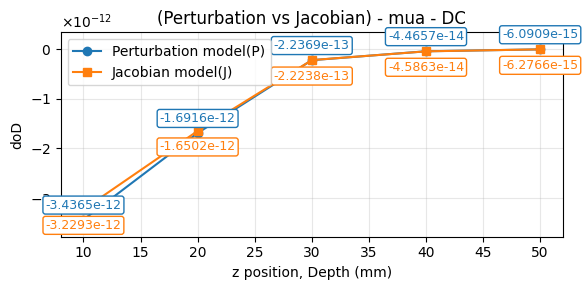

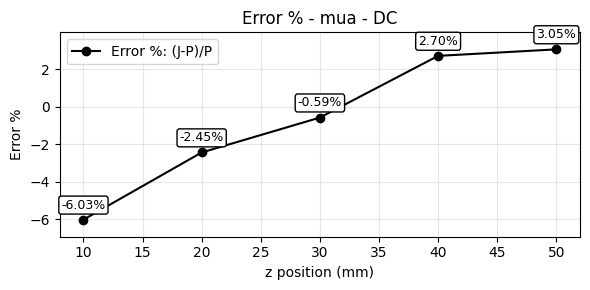

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Data
z_positions = []                   # creating an array that contains inclusion positions
for i in range(1, nPos+1):   
    z_positions.append(step * i)     
#print(z_positions)
x = z_positions
y_pert = doD_mua_pert[::-1]     # reversing to make it user friendly while displaying output(to display in ascending order of depth)
y_jac  = doD_mua_jacobian[::-1]
y_error = error_mua[::-1]    # reversing to make it user friendly while displaying output(to display in ascending order of depth)




# Comparison Plot
plt.figure(figsize=(6, 3))
line1, = plt.plot(x, y_pert, marker='o', linewidth=1.5, label='Perturbation model(P)')
line2, = plt.plot(x, y_jac,  marker='s', linewidth=1.5, label='Jacobian model(J)')
# Scientific notation for small values
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))
# Zoom y-limits with padding
y_min = min(np.min(y_pert), np.min(y_jac))
y_max = max(np.max(y_pert), np.max(y_jac))
pad = 0.1 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)
# Annotations: values at each point, colored by series and offset to avoid overlap
c1 = line1.get_color()
c2 = line2.get_color()
for xi, yi in zip(x, y_pert):
    ax.annotate(f'{yi:.4e}', (xi, yi),
                textcoords='offset points', xytext=(0, 8), ha='center',
                color=c1, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c1, alpha=1))
for xi, yi in zip(x, y_jac):
    ax.annotate(f'{yi:.4e}', (xi, yi),
                textcoords='offset points', xytext=(0, -14), ha='center',
                color=c2, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c2, alpha=1))
plt.xlabel('z position, Depth (mm)')
plt.ylabel('doD')
plt.title('(Perturbation vs Jacobian) - mua - DC')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()






# Error Plot
plt.figure(figsize=(6, 3))
line_err, = plt.plot(x, y_error, marker='o', linewidth=1.5, color='black', label='Error %: (J-P)/P')
# Zoom in around the min/max range with 10% padding
y_min = np.min(y_error)
y_max = np.max(y_error)
pad = 0.1 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)
# Get the line color
c_err = line_err.get_color()
# Annotate each point
for xi, yi in zip(x, y_error):
    plt.annotate(f'{yi:.2f}%', (xi, yi),
                 textcoords='offset points', xytext=(0, 8), ha='center',
                 color=c_err, fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c_err, alpha=1))
plt.xlabel('z position (mm)')
plt.ylabel('Error %')
plt.title('Error % - mua - DC')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



#### TEST 2: comparing [mus-Perturbation method-doD    vs     mus-jacobian method-doD] for DC mesh

In [113]:
#Scan parameters
start = 10
stop = 50
step = 10

posList = range(start,stop+1,step)
nPos = len(posList)

In [114]:
J_DC_mus = mesh.jacobian(normalize=False,mus=True)[0]     # mua-Jacobian of main mesh
J_DC_mus = J_DC_mus[:,:xgrid.size * ygrid.size * zgrid.size]    #(1, 1728000) # extracting just the mus part of the jacobian

data_DC = mesh.femdata(0)[0]                     # measured DC boundary data 
data_DC = data_DC.amplitude




doD_mus_pert = np.zeros(nPos)
doD_mus_jacobian = np.zeros(nPos)
error_mus = np.zeros(nPos)

print('\n')

# mua_back = np.zeros(nPos)
# mua_inc = np.zeros(nPos)
# mus_back = np.zeros(nPos)
# mus_inc = np.zeros(nPos)

pos_inc = []

for i in range(0,nPos):
   mesh_pert = ff.base.stndmesh()   # creating duplicate of mesh for measuring mus-perturbed-perturbation-model doD
   mesh_pert.from_copy(mesh)       
   


   # add a spherical absorption inclusion in mesh_pert
   dia_sc = 2    #diameter of spherical absorber
   x_cen_sc,y_cen_sc,z_cen_sc = [30,30,posList[i]]      #centre of the absorber
   dist_sc = np.sqrt(np.square((mesh.nodes[:,0]-x_cen_sc)) + np.square((mesh.nodes[:,1]-y_cen_sc)) + np.square((mesh.nodes[:,2]-z_cen_sc)))
   ind_sc = dist_sc < dia_sc/2
   mus_selection = np.where(ind_sc)           #of all node points, this is the selection of nodes where the absorber inclusion exists



   # Modify the mus-map of mesh_pert(in mesh-space) by some percentage, and calculate the forward data and sebsequently the perturbation doD
   mesh_pert.mus[mus_selection] = mesh.mus[mus_selection] + mus_pert_percent*mesh.mus[mus_selection] 
   mesh_pert.kappa[mus_selection] = 1.0 / (3.0*(mesh_pert.mua[mus_selection] + mesh_pert.mus[mus_selection]))

   # pos_inc.append(mus_selection)
   # musSelect = mesh_pert.mua[mus_selection]
   # mua_inc[i] = musSelect[0]
   # mus_inc[i] = mesh_pert.mus[mus_selection][0]
   # mua_back[i] = mesh_pert.mua[0]
   # mus_back[i] = mesh_pert.mus[0]

   data_mesh_pert = mesh_pert.femdata(0)[0] 
   data_mesh_pert = data_mesh_pert.amplitude


   doD_mus_pert[i] = (data_mesh_pert - data_DC).item()
  

   # Now calculate doD using the Jacobian method
   # creating the difference in absorption for selected nodes(to be multiplied with mua-Jacobian) in mesh-space and then interpolated to grid-space 
   tmp1= np.zeros(len(mesh.nodes))    #all meshes are derived from the original main 'mesh', hence its alright to use 'mesh.nodes'
   tmp1[mus_selection] = mus_pert_percent*mesh.mus[mus_selection]         # this is the effective difference in abs (in mesh-space). a 1% change in 'just absorption' 
   dmus = mesh.vol.mesh2grid@tmp1     # mesh to grid interpolation (difference in abs in grid-space) - (1728000,1)
   doD_mus_jacobian[i] = (J_DC_mus @ dmus).item()



   error_mus[i] = (((doD_mus_jacobian[i]-doD_mus_pert[i])/doD_mus_pert[i])*100)

   #Compare
   print(f"doD from US-perturbed-absorption-blob-perturbation model at z = {cube_grid_dim-((i+1)*step)} mm:", doD_mus_pert[i])
   print(f"doD from US-perturbed-absorption-blob-Jacobian: model at z = {cube_grid_dim-((i+1)*step)} mm:", doD_mus_jacobian[i])
   
   print('percentage error:' , error_mus[i])
   print('\n')


Calculating direct field...
Calculating adjoint field...
Integrating...


doD from US-perturbed-absorption-blob-perturbation model at z = 50 mm: 7.133244343105307e-15
doD from US-perturbed-absorption-blob-Jacobian: model at z = 50 mm: 7.140275746306333e-15
percentage error: 0.09857230262724434


doD from US-perturbed-absorption-blob-perturbation model at z = 40 mm: 3.0385202952907045e-14
doD from US-perturbed-absorption-blob-Jacobian: model at z = 40 mm: 3.105471794806356e-14
percentage error: 2.203424463526459


doD from US-perturbed-absorption-blob-perturbation model at z = 30 mm: 1.0111092430713838e-14
doD from US-perturbed-absorption-blob-Jacobian: model at z = 30 mm: 1.0674381549467508e-14
percentage error: 5.571001576868207


doD from US-perturbed-absorption-blob-perturbation model at z = 20 mm: -1.8026026046219035e-12
doD from US-perturbed-absorption-blob-Jacobian: model at z = 20 mm: -1.835971129718349e-12
percentage error: 1.8511304161487445


doD from US-perturbed-absorption-

#### plots

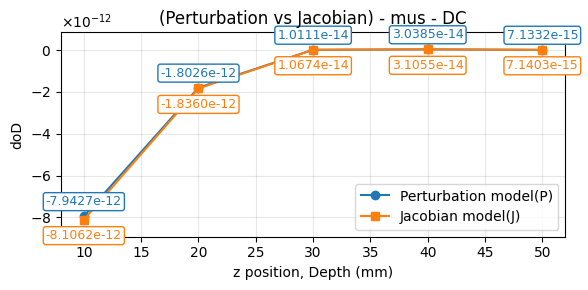

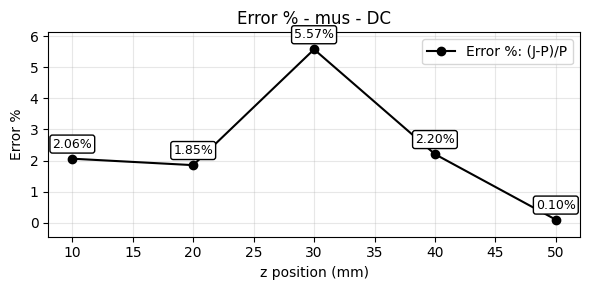

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Data
z_positions = []                   # creating an array that contains inclusion positions
for i in range(1, nPos+1):   
    z_positions.append(step * i)     
#print(z_positions)

x = z_positions
y_pert = doD_mus_pert[::-1]     # reversing to make it user friendly while displaying output(to display in ascending order of depth)
y_jac  = doD_mus_jacobian[::-1]
y_error = error_mus[::-1]    # reversing to make it user friendly while displaying output(to display in ascending order of depth)





# Comparison Plot
plt.figure(figsize=(6, 3))
line1, = plt.plot(x, y_pert, marker='o', linewidth=1.5, label='Perturbation model(P)')
line2, = plt.plot(x, y_jac,  marker='s', linewidth=1.5, label='Jacobian model(J)')
# Scientific notation for small values
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))
# Zoom y-limits with padding
y_min = min(np.min(y_pert), np.min(y_jac))
y_max = max(np.max(y_pert), np.max(y_jac))
pad = 0.1 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)
# Annotations: values at each point, colored by series and offset to avoid overlap
c1 = line1.get_color()
c2 = line2.get_color()
for xi, yi in zip(x, y_pert):
    ax.annotate(f'{yi:.4e}', (xi, yi),
                textcoords='offset points', xytext=(0, 8), ha='center',
                color=c1, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c1, alpha=1))
for xi, yi in zip(x, y_jac):
    ax.annotate(f'{yi:.4e}', (xi, yi),
                textcoords='offset points', xytext=(0, -14), ha='center',
                color=c2, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c2, alpha=1))
plt.xlabel('z position, Depth (mm)')
plt.ylabel('doD')
plt.title('(Perturbation vs Jacobian) - mus - DC')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()






# Error Plot
plt.figure(figsize=(6, 3))
line_err, = plt.plot(x, y_error, marker='o', linewidth=1.5, color='black', label='Error %: (J-P)/P')
# Zoom in around the min/max range with 10% padding
y_min = np.min(y_error)
y_max = np.max(y_error)
pad = 0.1 * (y_max - y_min)
plt.ylim(y_min - pad, y_max + pad)
# Get the line color
c_err = line_err.get_color()
# Annotate each point
for xi, yi in zip(x, y_error):
    plt.annotate(f'{yi:.2f}%', (xi, yi),
                 textcoords='offset points', xytext=(0, 8), ha='center',
                 color=c_err, fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=c_err, alpha=1))
plt.xlabel('z position (mm)')
plt.ylabel('Error %')
plt.title('Error % - mus - DC')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

